# **Logistic Regression (Loan Approval Prediction)**

# **Assignment Questions**

## **Q1. Data Loading & Understanding**  
a) Load the dataset into Python.  
b) Display the first 5 rows.  
c) Check the shape of the dataset.  
d) Display the data types of each column.

## **Solution:**

### **a) Load the dataset**

In [2]:
import pandas as pd

df = pd.read_csv("loan_approval - loan_approval.csv")

### **b) Display the first 5 rows**

In [3]:
df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


### **c) Check shape of dataset**

In [4]:
df.shape

(2000, 8)

#### **Output interpretation:**  
- First value = number of rows  
- Second value = number of columns

### **d) Display data types**

In [5]:
df.dtypes

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

## **Q2. Data Cleaning**  
a) Check for missing values in the dataset.  
b) Handle missing values appropriately.  
c) Identify categorical columns present in the dataset.

## **Solution:**

### **a) Check for missing values**

In [6]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

#### **Interpretation:**  
- Shows count of missing values in each column
- There are no missing values

### **b) Handle missing values**

In [7]:
# Since the dataset has no missing values, no action required
df = df.copy()

#### **Dataset insight:**  
- No missing values found → data is already clean  
- No imputation required

### **c) Identify categorical columns**

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
categorical_cols

Index(['name', 'city', 'loan_approved'], dtype='object')

## **Q3. Exploratory Data Analysis (EDA)**  
a) Plot the distribution of the target variable.  
b) Analyze the relationship between one numerical feature and the target variable.  
c) Analyze the relationship between Years of Employment and the target variable.

## **Solution:**

### **a) Distribution of Target Variable**

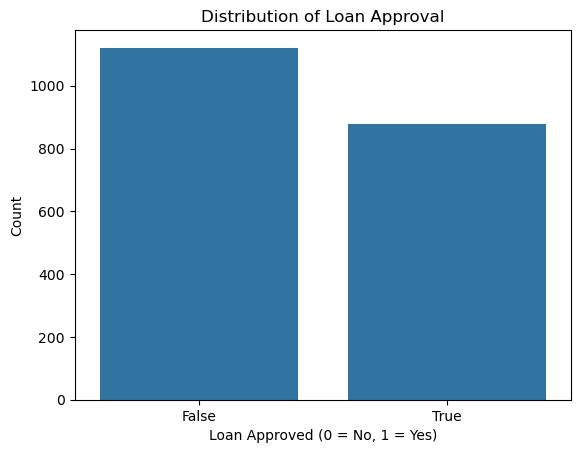

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)
plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### **Interpretation**  
- The target variable shows how many loans were approved vs rejected
- Helps identify class imbalance (if any)

### **b) Relationship between Numerical Feature and Target**

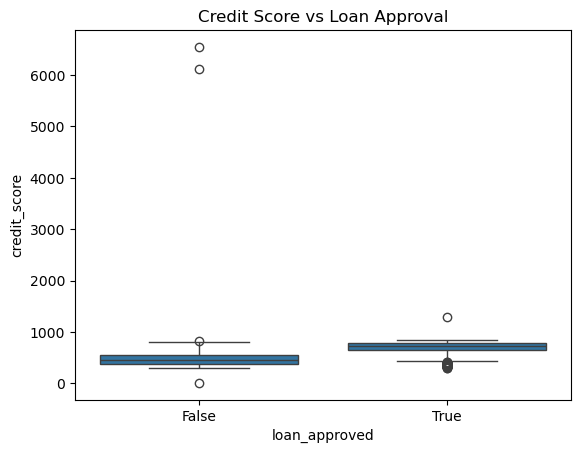

In [10]:
sns.boxplot(x='loan_approved', y='credit_score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

### **Interpretation**  
- Higher credit scores are associated with higher chances of loan approval
- Indicates strong positive relationship with target variable

### **c) Years of Employment vs Target**

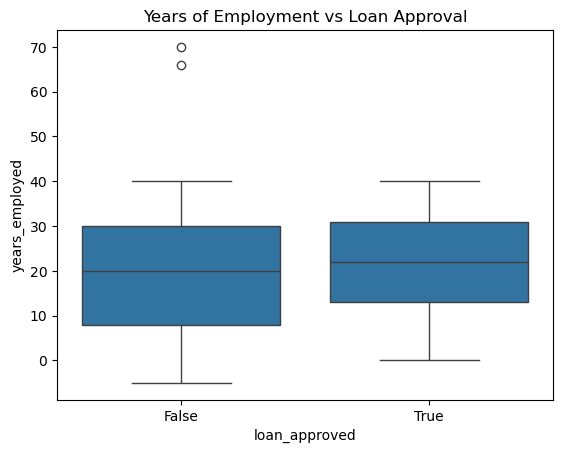

In [11]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years of Employment vs Loan Approval")
plt.show()

### **Interpretation**  
- Applicants with more years of employment tend to have higher approval rates
- Indicates job stability is an important factor

## **Q4. Outlier Detection and Treatment**  
a) Detect outliers in numerical columns using the IQR method.  
b) Treat outliers using capping techniques

## **Solution:**

### **a) Detect Outliers using IQR Method**

In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {outliers.shape[0]} outliers")

income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


### **Interpretation**  
- Income: No outliers detected → values are well distributed    
- Credit Score: 3 outliers detected → few extreme values present  
- Loan Amount: No outliers detected → stable distribution  
- Years Employed: 2 outliers detected → some unusually high/low experience values  
- Points: No outliers detected → consistent data  

Overall, the dataset contains very few outliers, mainly in credit score and years employed. 
These outliers will be treated using capping to maintain data integrity without removing records.

### **b) Treat Outliers using Capping (Winsorization)**

In [14]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

### **What this does:**  
- Replaces extreme values with boundary values  
- Keeps data size same (better than deleting rows)

## **Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.**

## **Solution:**

### **Convert Target Variable to Numeric**

In [15]:
df['loan_approved'] = df['loan_approved'].astype(int)

### **Explanation:**  
- Converts True/False → 1/0  
- Required for Logistic Regression

### **Drop Unnecessary Columns**

In [16]:
df = df.drop(['name', 'city'], axis=1)

### **Data Preparation**  
- The target variable 'loan_approved' was converted into numerical format (0 and 1)
- Unnecessary columns such as 'name' and 'city' were removed
- This ensures the dataset is suitable for model building

## **Q6. Feature Selection and Data Splitting**  
a) Separate independent variables (X) and dependent variable (y).  
b) Split the dataset into training and testing sets.

## **Solution:**

### **a) Separate Independent (X) and Dependent Variable (y)**

In [17]:
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

### **Explanation:**  
- X → all input features  
- y → target variable (loan approval)

### **b) Train-Test Split**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Explanation:**  
- 80% data → training  
- 20% data → testing  
- random_state=42 → ensures reproducibility

## **Q7. Apply feature scaling to the dataset using StandardScaler.**

### **Apply StandardScaler** 

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform
X_train = scaler.fit_transform(X_train)

# Only transform test data
X_test = scaler.transform(X_test)

### **Interpretation**  
- StandardScaler was used to standardize the features
- It transforms data to have mean = 0 and standard deviation = 1
- Scaling was applied on training data and then used to transform test data

## **Q8. Logistic Regression Model Building**  
a) Train a Logistic Regression model.  
b) Predict the output for test data.

## **Solution:**

### **a) Train the Logistic Regression Model**

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### **Explanation:**  
- Model is trained on scaled training data  
- max_iter=1000 ensures convergence

### **b) Predict Output on Test Data**

In [21]:
y_pred = model.predict(X_test)

### **Explanation:**  
- Generates predicted class labels (0 or 1)  
- Based on learned patterns from training data

## **Q9. Model Evaluation – Confusion Matrix**  
a) Generate the confusion matrix.  
b) Interpret the results.

## **Solution:**

### **a) Generate Confusion Matrix**

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[217   0]
 [  0 183]]


### **Visualization**

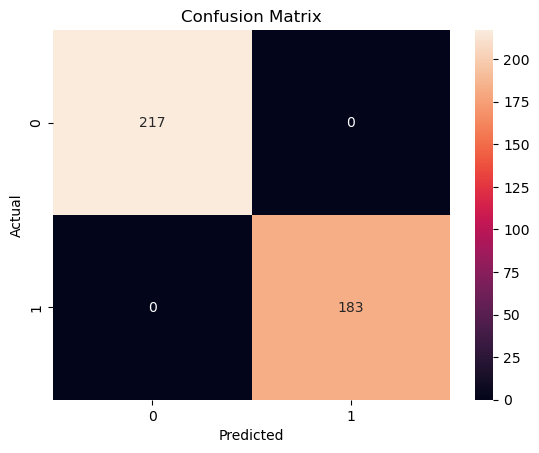

In [23]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **b) Interpretation of Results**

 **The confusion matrix obtained is:**  
[[217   0]  
 [  0 183]]

- True Negatives (TN) = 217 → correctly predicted loan rejections  
- True Positives (TP) = 183 → correctly predicted loan approvals  
- False Positives (FP) = 0 → no incorrect approvals  
- False Negatives (FN) = 0 → no missed approvals  

The model has achieved perfect classification on the test dataset with zero errors. 
This indicates that the model is highly accurate and can distinguish between approved and rejected loans very effectively.

## **Q10. Model Evaluation – ROC Curve & AUC**  
a) Plot the ROC curve.  
b) Calculate the AUC score.

## **Solution:**

### **a) Plot ROC Curve**


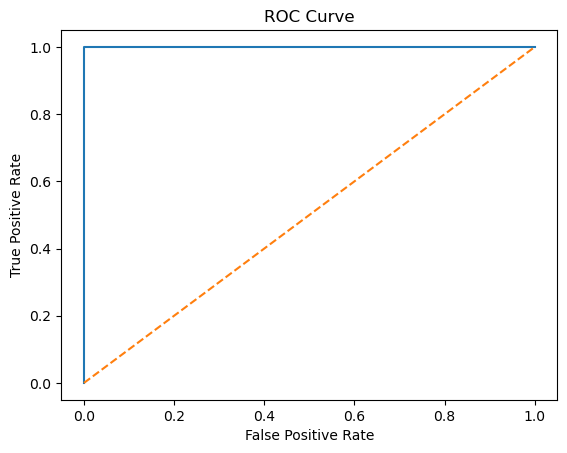

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### **b) Calculate AUC Score**

In [25]:
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 1.0


### **ROC Curve & AUC Interpretation**  
- The ROC curve shows the trade-off between True Positive Rate and False Positive Rate
- The curve is expected to be very close to the top-left corner
- AUC Score = 1.0 indicates perfect model performance
- The model can perfectly distinguish between approved and rejected loans

This confirms the model has excellent classification capability.